# 🚗 Predictive Modeling of Traffic Collision Severity in New York City
### Final Project — Sistem Cerdas
**Model:** Artificial Neural Network (Multilayer Perceptron)  
**Dataset:** [NYC Open Data — Motor Vehicle Collisions](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95)  

| Class | Label |
|-------|-------|
| 0 | Safe / Property Damage Only |
| 1 | Injury / Fatal |

---
## STEP 0 — Imports & Configuration

In [16]:
import os, warnings, requests
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
CSV_PATH = os.path.join(DATA_DIR, 'NYC_Collisions.csv')
print(f'Base: {BASE_DIR}\nData: {DATA_DIR}\nModels: {MODELS_DIR}')

Base: d:\Mikail\SC_NYC_Collisions\backend
Data: d:\Mikail\SC_NYC_Collisions\backend\data
Models: d:\Mikail\SC_NYC_Collisions\backend\models


---
## STEP 1 — Data Acquisition

In [17]:
if os.path.exists(CSV_PATH):
    print(f'Dataset already exists at: {CSV_PATH}')
    df = pd.read_csv(CSV_PATH)
else:
    print('Downloading dataset from NYC Open Data API...')
    API_URL = 'https://data.cityofnewyork.us/resource/h9gi-nx95.json'
    all_records = []
    for offset in range(0, 50000, 5000):
        print(f'  Fetching records {offset} to {offset+5000}...')
        resp = requests.get(API_URL, params={'$limit': 5000, '$offset': offset})
        if resp.status_code != 200: break
        batch = resp.json()
        if not batch: break
        all_records.extend(batch)
    df = pd.DataFrame(all_records)
    df.to_csv(CSV_PATH, index=False)
    print(f'Saved {len(df)} records')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset already exists at: d:\Mikail\SC_NYC_Collisions\backend\data\NYC_Collisions.csv
Dataset shape: (50000, 29)


,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2021-09-11T00:00:00.000,2:39,WHITESTONE EXPRESSWAY,20 AVENUE,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-03-26T00:00:00.000,11:45,QUEENSBORO BRIDGE UPPER,NaN,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01T00:00:00.000,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,40.62179,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN
3,2022-06-29T00:00:00.000,6:55,THROGS NECK BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-21T00:00:00.000,13:21,BROOKLYN BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## STEP 2 — Feature Engineering & Target Creation

In [18]:
# Standardize column names
df.columns = df.columns.str.upper().str.replace(' ', '_')
if 'VEHICLE_TYPE_CODE_1' not in df.columns and 'VEHICLE_TYPE_CODE1' in df.columns:
    df.rename(columns={'VEHICLE_TYPE_CODE1': 'VEHICLE_TYPE_CODE_1'}, inplace=True)

# Convert numeric columns
df['NUMBER_OF_PERSONS_INJURED'] = pd.to_numeric(df['NUMBER_OF_PERSONS_INJURED'], errors='coerce').fillna(0).astype(int)
df['NUMBER_OF_PERSONS_KILLED'] = pd.to_numeric(df['NUMBER_OF_PERSONS_KILLED'], errors='coerce').fillna(0).astype(int)

# Binary Target
df['SEVERITY_CLASS'] = ((df['NUMBER_OF_PERSONS_KILLED'] > 0) | (df['NUMBER_OF_PERSONS_INJURED'] > 0)).astype(int)

# Extract CRASH_HOUR
def extract_hour(t):
    try: return int(str(t).strip().split(':')[0])
    except: return 12
df['CRASH_HOUR'] = df['CRASH_TIME'].apply(extract_hour)

# Extract DAY_OF_WEEK (0=Monday, 6=Sunday) and MONTH
df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'], errors='coerce')
df['DAY_OF_WEEK'] = df['CRASH_DATE'].dt.dayofweek.fillna(0).astype(int)
df['MONTH'] = df['CRASH_DATE'].dt.month.fillna(1).astype(int)

# Count vehicles for statistics (NOT model input)
def count_vehicles(row):
    count = 0
    for c in ['VEHICLE_TYPE_CODE_1','VEHICLE_TYPE_CODE2','VEHICLE_TYPE_CODE_3','VEHICLE_TYPE_CODE_4','VEHICLE_TYPE_CODE_5']:
        if c in row and pd.notnull(row[c]) and str(row[c]).strip() != '': count += 1
    return max(1, count)
df['NUM_VEHICLES'] = df.apply(count_vehicles, axis=1)

print('Target Variable Distribution:')
print(df['SEVERITY_CLASS'].value_counts().sort_index())
print(f'\n  Class 0 (Safe):         {(df["SEVERITY_CLASS"]==0).sum()}')
print(f'  Class 1 (Injury/Fatal): {(df["SEVERITY_CLASS"]==1).sum()}')

Target Variable Distribution:
SEVERITY_CLASS
0    32274
1    17726
Name: count, dtype: int64

  Class 0 (Safe):         32274
  Class 1 (Injury/Fatal): 17726


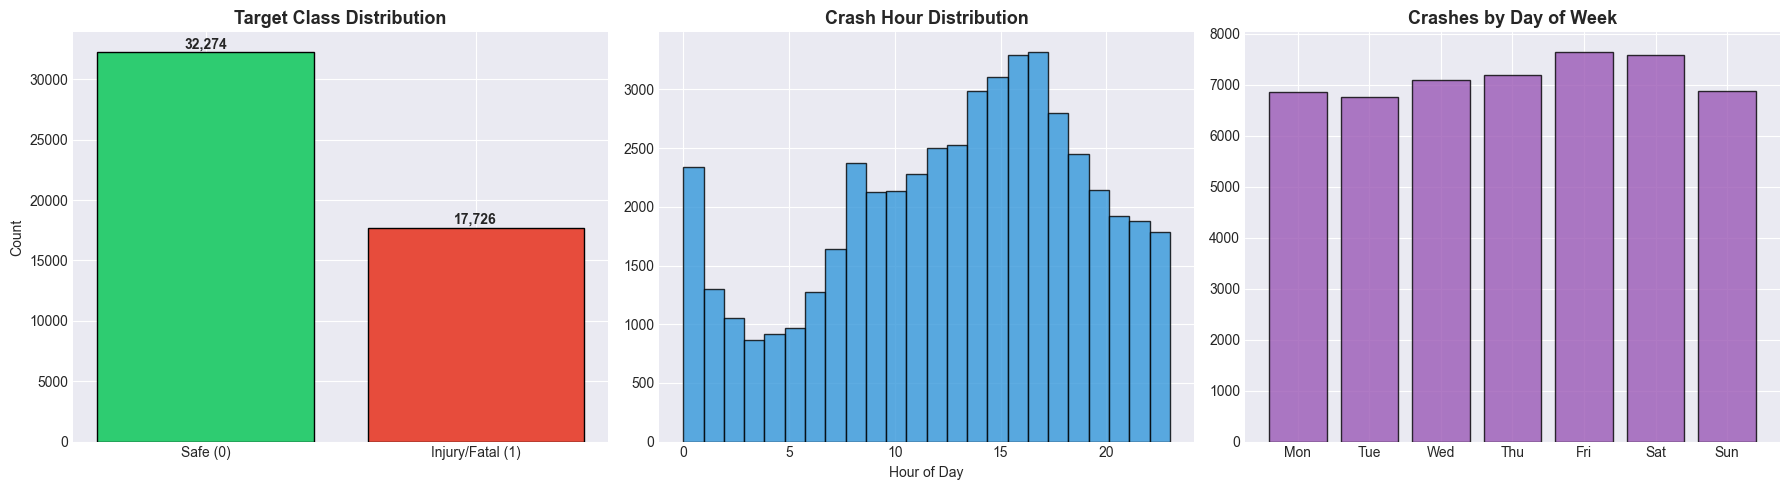

In [19]:
# Visualize Target + Crash Hour Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#e74c3c']
counts = df['SEVERITY_CLASS'].value_counts().sort_index()
axes[0].bar(['Safe (0)', 'Injury/Fatal (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

df['CRASH_HOUR'].hist(bins=24, ax=axes[1], color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Crash Hour Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = df['DAY_OF_WEEK'].value_counts().sort_index()
axes[2].bar(day_names, day_counts.values, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[2].set_title('Crashes by Day of Week', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## STEP 3 — Data Preprocessing

In [20]:
feature_cols = ['CRASH_HOUR', 'DAY_OF_WEEK', 'MONTH', 'BOROUGH', 'VEHICLE_TYPE_CODE_1', 'CONTRIBUTING_FACTOR_VEHICLE_1']
target_col = 'SEVERITY_CLASS'
df_model = df[feature_cols + [target_col]].copy()

# Handle missing values
df_model['CRASH_HOUR'] = df_model['CRASH_HOUR'].fillna(12)
df_model['DAY_OF_WEEK'] = df_model['DAY_OF_WEEK'].fillna(0)
df_model['MONTH'] = df_model['MONTH'].fillna(1)
df_model['BOROUGH'] = df_model['BOROUGH'].fillna('UNKNOWN')
df_model['VEHICLE_TYPE_CODE_1'] = df_model['VEHICLE_TYPE_CODE_1'].fillna('UNKNOWN')
df_model['CONTRIBUTING_FACTOR_VEHICLE_1'] = df_model['CONTRIBUTING_FACTOR_VEHICLE_1'].fillna('UNKNOWN')

categorical_cols = ['BOROUGH', 'VEHICLE_TYPE_CODE_1', 'CONTRIBUTING_FACTOR_VEHICLE_1']
numerical_cols = ['CRASH_HOUR', 'DAY_OF_WEEK', 'MONTH']

for col in categorical_cols:
    df_model[col] = df_model[col].astype(str).str.strip().str.upper()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

feature_columns_ordered = numerical_cols + categorical_cols
X = preprocessor.fit_transform(df_model[feature_columns_ordered])
y = df_model[target_col].values

# Save preprocessor & categories
joblib.dump(preprocessor, os.path.join(MODELS_DIR, 'preprocessor.pkl'))
categories_info = {
    'BOROUGH': list(preprocessor.named_transformers_['cat'].categories_[0]),
    'VEHICLE_TYPE_CODE_1': list(preprocessor.named_transformers_['cat'].categories_[1]),
    'CONTRIBUTING_FACTOR_VEHICLE_1': list(preprocessor.named_transformers_['cat'].categories_[2]),
}
joblib.dump(categories_info, os.path.join(MODELS_DIR, 'categories_info.pkl'))

# Save vehicle stats for API insights
vehicle_stats = df.groupby(['BOROUGH','SEVERITY_CLASS'])['NUM_VEHICLES'].describe().reset_index()
joblib.dump(df[['BOROUGH','VEHICLE_TYPE_CODE_1','CONTRIBUTING_FACTOR_VEHICLE_1','NUM_VEHICLES','SEVERITY_CLASS']].copy(), os.path.join(MODELS_DIR, 'vehicle_stats.pkl'))

print(f'X shape after preprocessing: {X.shape}')
print(f'y shape: {y.shape}')

X shape after preprocessing: (50000, 235)
y shape: (50000,)


In [21]:
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train = to_categorical(y_train_int, num_classes=2)
y_test  = to_categorical(y_test_int, num_classes=2)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 40000 | Test: 10000


---
## STEP 4 — Build & Train the ANN (MLP)

In [22]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax'),
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        60,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,698 (397.26 KB)

 Trainable params: 101,698 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6682 - loss: 0.6208 - val_accuracy: 0.6951 - val_loss: 0.5946
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6910 - loss: 0.6002 - val_accuracy: 0.6973 - val_loss: 0.5916
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6952 - loss: 0.5948 - val_accuracy: 0.6981 - val_loss: 0.5905
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6964 - loss: 0.5929 - val_accuracy: 0.6980 - val_loss: 0.5897
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6977 - loss: 0.5905 - val_accuracy: 0.6980 - val_loss: 0.5900
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6978 - loss: 0.5899 - val_accuracy: 0.6994 - val_loss: 0.5900
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6994 - loss: 0.5877 - val_accuracy: 0.6988 - val_loss: 0.5900
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6992 - loss: 0.5858 - val_accu

---
## STEP 5 — Evaluation & Visualization

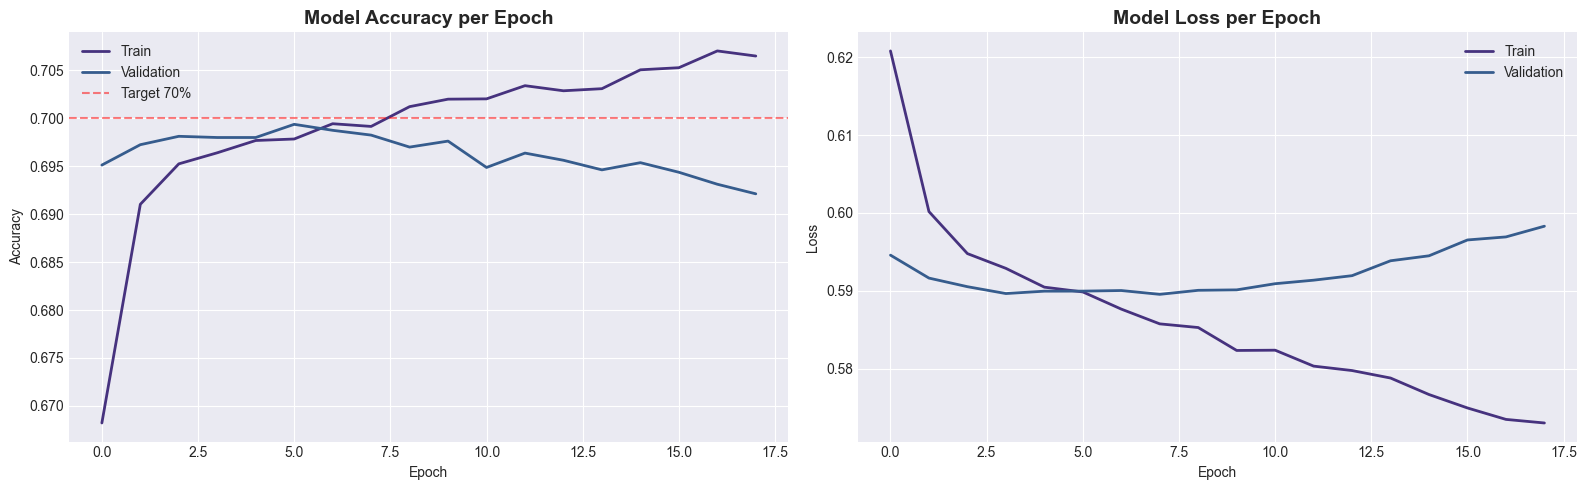

In [24]:
# Accuracy & Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].axhline(y=0.70, color='r', linestyle='--', alpha=0.5, label='Target 70%')
axes[0].set_title('Model Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n{"="*50}')
print(f'  TEST ACCURACY : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  TEST LOSS     : {test_loss:.4f}')
print(f'{"="*50}')
print('\n✅ TARGET ACHIEVED!' if test_acc >= 0.70 else f'\n⚠️ Below target: {test_acc*100:.2f}%')


  TEST ACCURACY : 0.7050 (70.50%)
  TEST LOSS     : 0.5837

✅ TARGET ACHIEVED!


In [26]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)
class_names = ['Safe (Class 0)', 'Injury/Fatal (Class 1)']
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
                        precision    recall  f1-score   support

        Safe (Class 0)       0.71      0.92      0.80      6455
Injury/Fatal (Class 1)       0.69      0.31      0.42      3545

              accuracy                           0.70     10000
             macro avg       0.70      0.62      0.61     10000
          weighted avg       0.70      0.70      0.67     10000



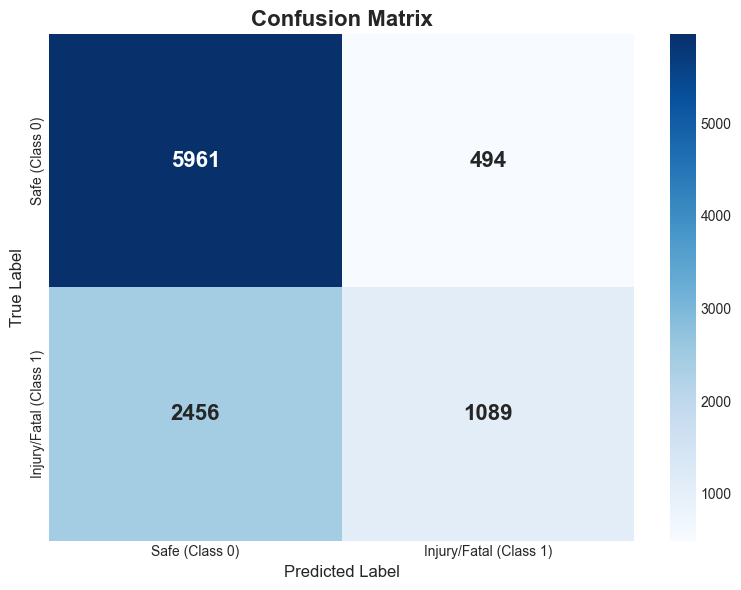

In [27]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax, annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12); ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout(); plt.show()

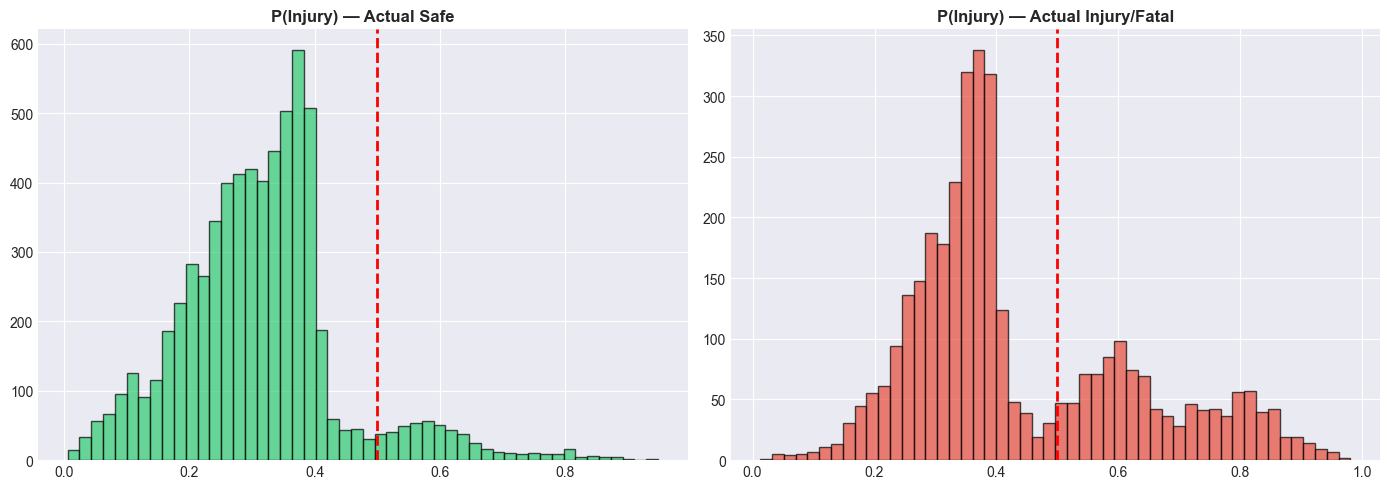

In [28]:
# Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_pred_proba[y_true==0][:,1], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[0].set_title('P(Injury) — Actual Safe', fontsize=12, fontweight='bold')
axes[1].hist(y_pred_proba[y_true==1][:,1], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[1].set_title('P(Injury) — Actual Injury/Fatal', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## STEP 6 — Export Model

In [29]:
model.save(os.path.join(MODELS_DIR, 'severity_model.h5'))
model.save(os.path.join(MODELS_DIR, 'severity_model.keras'))
print('Exported to:', MODELS_DIR)
print('  - severity_model.h5 / .keras')
print('  - preprocessor.pkl')
print('  - categories_info.pkl')
print('  - vehicle_stats.pkl')
print('\n✅ TRAINING COMPLETE!')

Exported to: d:\Mikail\SC_NYC_Collisions\backend\models
  - severity_model.h5 / .keras
  - preprocessor.pkl
  - categories_info.pkl
  - vehicle_stats.pkl

✅ TRAINING COMPLETE!


---
## STEP 7 — Sample Prediction (Demo)

In [30]:
sample = pd.DataFrame([{'CRASH_HOUR': 23, 'DAY_OF_WEEK': 5, 'MONTH': 12, 'BOROUGH': 'MANHATTAN', 'VEHICLE_TYPE_CODE_1': 'SEDAN', 'CONTRIBUTING_FACTOR_VEHICLE_1': 'ALCOHOL INVOLVEMENT'}])
pred = model.predict(preprocessor.transform(sample), verbose=0)
print(f'Input: Saturday night, Dec, Manhattan, Sedan, Alcohol')
print(f'  Safe:         {pred[0][0]*100:.2f}%')
print(f'  Injury/Fatal: {pred[0][1]*100:.2f}%')
print(f'  Predicted: {"⚠️ Injury/Fatal" if np.argmax(pred)==1 else "✅ Safe"}')

Input: Saturday night, Dec, Manhattan, Sedan, Alcohol
  Safe:         69.11%
  Injury/Fatal: 30.89%
  Predicted: ✅ Safe
